## Limpieza de datos, EDA y Visualizaciones

### Importación de librerias

In [45]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

#### Limpieza de datos

In [46]:
import os
import pandas as pd
ruta_csv = r"C:\prediccion_accidentes\data\raw\BD.csv"


In [47]:
df = pd.read_csv(ruta_csv, sep=';', encoding='utf-8')
print("Shape original:", df.shape)
df.head()

Shape original: (104898, 21)


,Clase de accidente,Tipo de accidente,Año,Hora,Hora recodificada,Provincia,Cantón,Distrito,Ruta,Kilómetro,...,Calzada vertical,Calzada horizontal,Tipo de calzada,Tipo de circulación,Estado del tiempo,Estado de la calzada,Región Mideplan,Tipo ruta,Día,Mes
0,Solo heridos leves,Salió de la vía,2024,20:00-20:59,18:00-23:59,Limón,Pococí,Guápiles,32,43,...,Pendiente,Curva,Asfalto,Lateral igual sentido,Lluvia,Resbaladiza,Huetar caribe,Nacional,7.Sábado,D. Abril
1,Solo heridos leves,Colisión con motocicleta,2024,06:00-06:59,06:00-11:59,Heredia,San Isidro,San José,32,12,...,Plano,Recta,Asfalto,Angulo recto,Buen tiempo,Buena,Central,Nacional,3.Martes,E. Mayo
2,Con muertos o graves,Vuelco,2024,15:00-15:59,12:00-17:59,San José,Vázquez de Coronado,Dulce Nombre de Jesús,32,21,...,Pendiente,Curva,Asfalto,Lateral igual sentido,Buen tiempo,Buena,Central,Nacional,6.Viernes,E. Mayo
3,Solo heridos leves,Colisión entre vehículos,2024,08:00-08:59,06:00-11:59,Heredia,Santo Domingo,San Miguel,32,7,...,Plano,Recta,Asfalto,Por detrás,Buen tiempo,Buena,Central,Nacional,3.Martes,G. Julio
4,Solo heridos leves,Colisión con motocicleta,2024,07:00-07:59,06:00-11:59,Heredia,Santo Domingo,San Miguel,32,5,...,Plano,Recta,Asfalto,Lateral igual sentido,Buen tiempo,Buena,Central,Nacional,3.Martes,H. Agosto


In [48]:
# Limpiar nombres de columnas
df.columns = df.columns.str.strip()
# Rellenar nulos en columnas de texto
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna('Desconocido').str.strip()
# Rellenar nulos numéricos con 0
df = df.fillna(0)
# Estandarizar Día y Mes
if 'Día' in df.columns:
    df['Día'] = df['Día'].astype(str).str.replace(r'^\d+\.', '', regex=True)
if 'Mes' in df.columns:
    df['Mes'] = df['Mes'].astype(str).str.replace(r'^[A-Z]\.\s?', '', regex=True)

print("Limpieza completada. Shape:", df.shape)
df.head()

Limpieza completada. Shape: (104898, 21)


,Clase de accidente,Tipo de accidente,Año,Hora,Hora recodificada,Provincia,Cantón,Distrito,Ruta,Kilómetro,...,Calzada vertical,Calzada horizontal,Tipo de calzada,Tipo de circulación,Estado del tiempo,Estado de la calzada,Región Mideplan,Tipo ruta,Día,Mes
0,Solo heridos leves,Salió de la vía,2024,20:00-20:59,18:00-23:59,Limón,Pococí,Guápiles,32,43,...,Pendiente,Curva,Asfalto,Lateral igual sentido,Lluvia,Resbaladiza,Huetar caribe,Nacional,Sábado,Abril
1,Solo heridos leves,Colisión con motocicleta,2024,06:00-06:59,06:00-11:59,Heredia,San Isidro,San José,32,12,...,Plano,Recta,Asfalto,Angulo recto,Buen tiempo,Buena,Central,Nacional,Martes,Mayo
2,Con muertos o graves,Vuelco,2024,15:00-15:59,12:00-17:59,San José,Vázquez de Coronado,Dulce Nombre de Jesús,32,21,...,Pendiente,Curva,Asfalto,Lateral igual sentido,Buen tiempo,Buena,Central,Nacional,Viernes,Mayo
3,Solo heridos leves,Colisión entre vehículos,2024,08:00-08:59,06:00-11:59,Heredia,Santo Domingo,San Miguel,32,7,...,Plano,Recta,Asfalto,Por detrás,Buen tiempo,Buena,Central,Nacional,Martes,Julio
4,Solo heridos leves,Colisión con motocicleta,2024,07:00-07:59,06:00-11:59,Heredia,Santo Domingo,San Miguel,32,5,...,Plano,Recta,Asfalto,Lateral igual sentido,Buen tiempo,Buena,Central,Nacional,Martes,Agosto


Llamamos las clases

In [65]:
from src.base_datos.GestorBaseDatos import GestorDatos
from src.eda.ProcesadorEDA import ProcesadorEDA
from src.descriptivas.visualizacion.Visualizador import Visualizador
from src.datos.GestorDatos import GestorDatos

print("Clases importadas correctamente")

Clases importadas correctamente


Cargado: 104898 filas, 21 columnas
Columnas limpias.
Nulos manejados.
Día/Mes estandarizados.


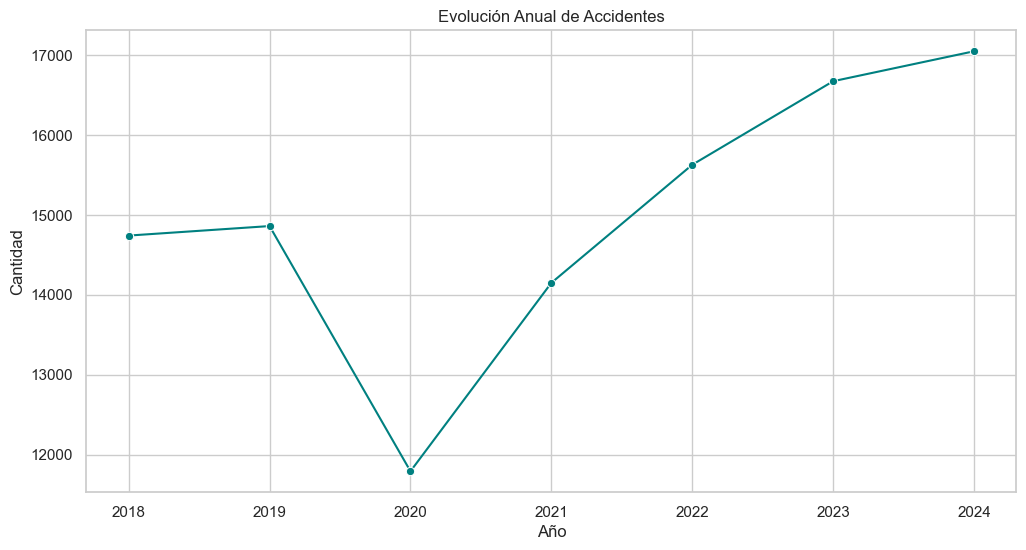

C:\prediccion_accidentes\src\eda\ProcesadorEDA.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=self.df, y='Provincia', order=order, palette='viridis')


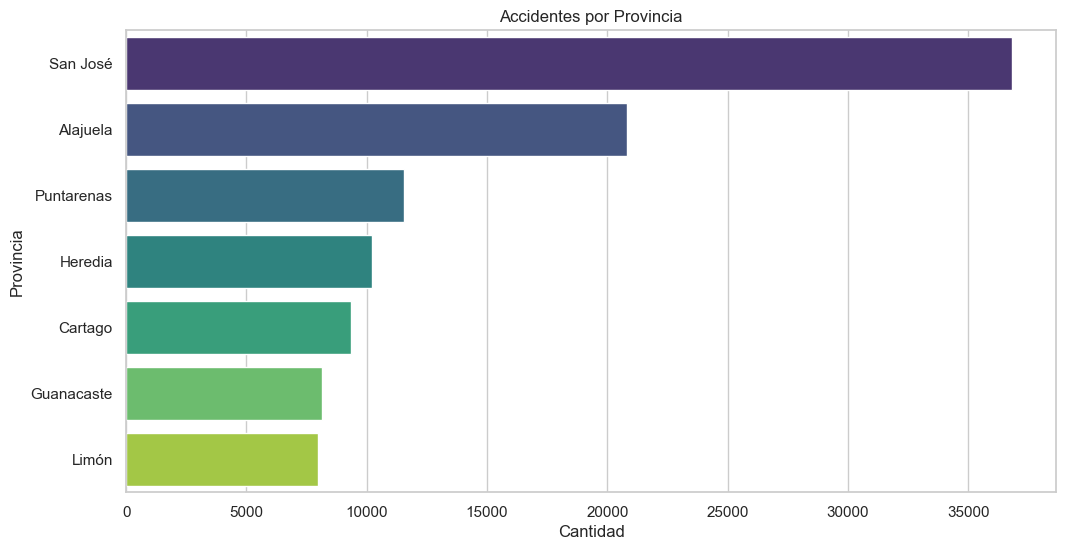

C:\prediccion_accidentes\src\eda\ProcesadorEDA.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.values, y=top10.index, palette='magma')


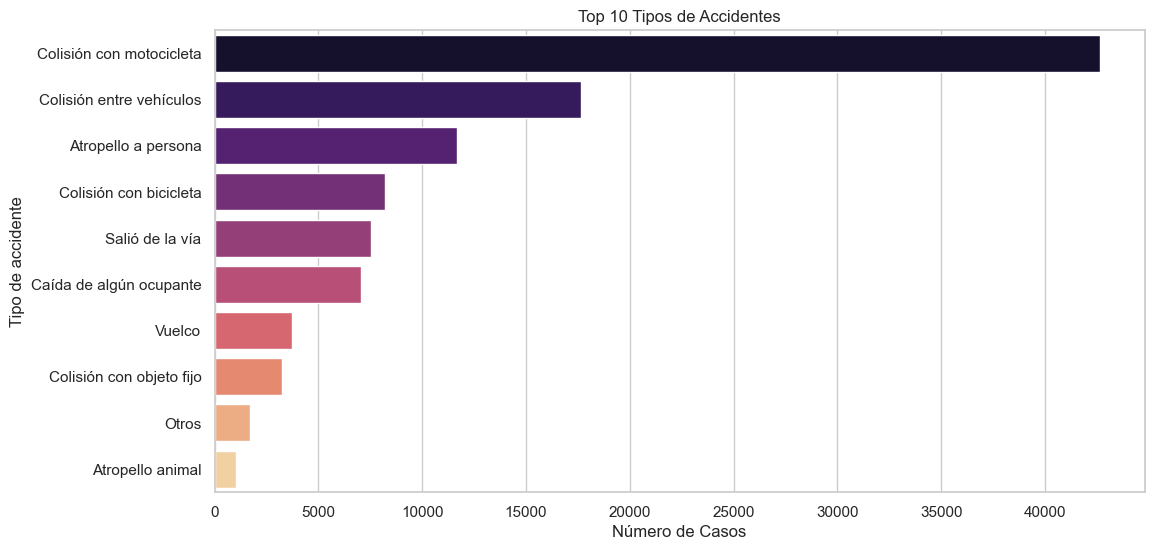

C:\prediccion_accidentes\src\eda\ProcesadorEDA.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=self.df, x='Día', order=orden, palette='coolwarm')


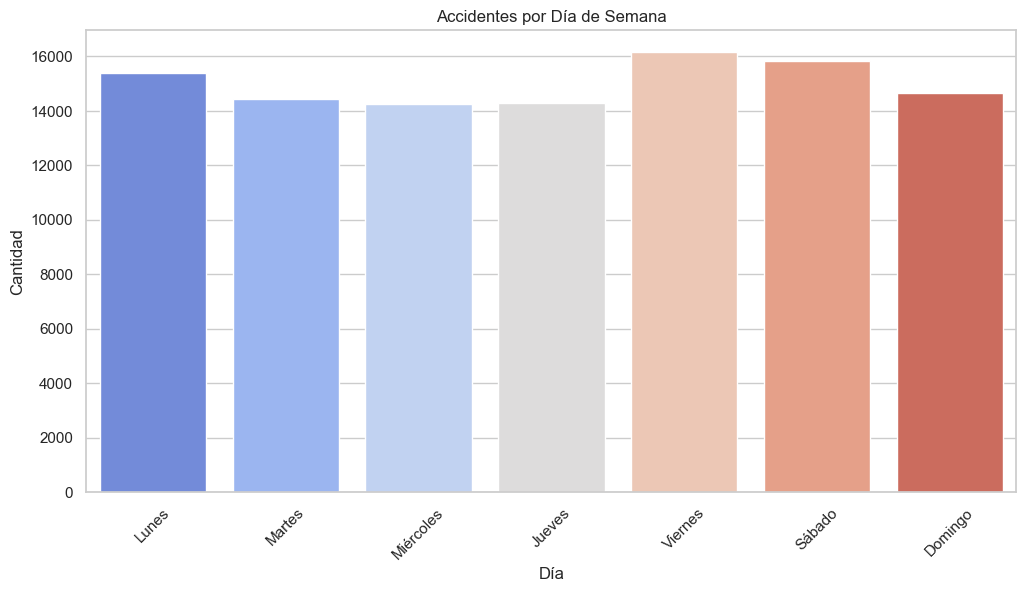

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Cargar y limpiar
gestor = GestorDatos(ruta_csv)
df = gestor.pipeline()

# EDA
eda = ProcesadorEDA(df)
eda.tendencia_anual()
eda.top_provincias()
eda.tipo_accidentes_top10()
eda.distribucion_semana()



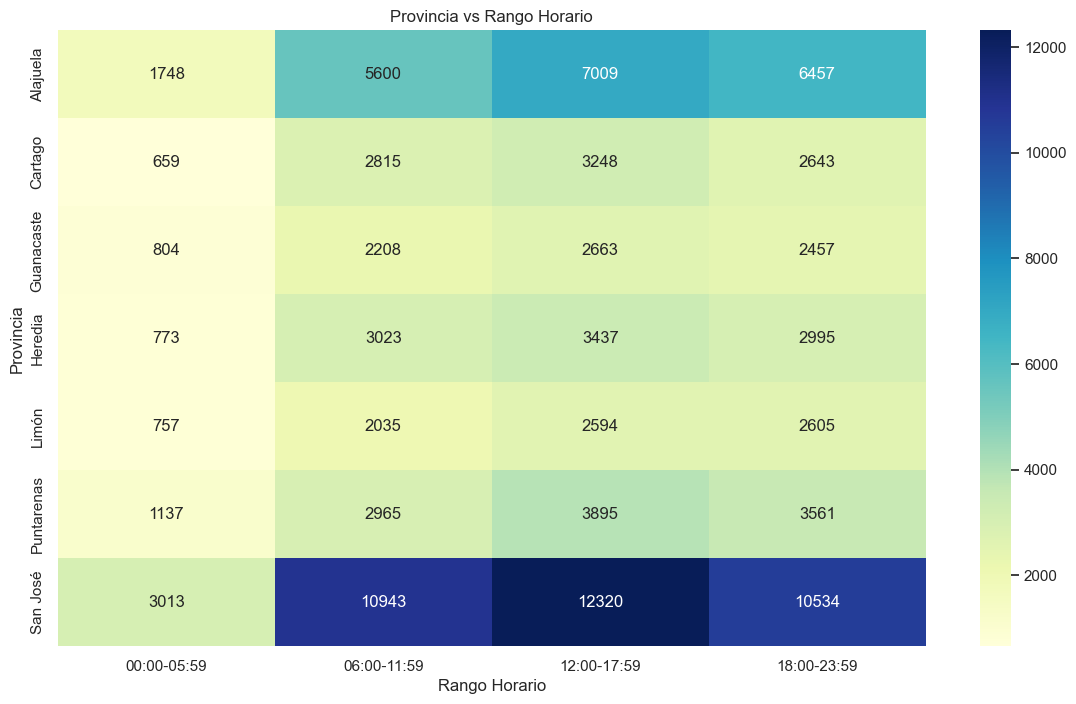

In [54]:
plt.figure(figsize=(14,8))
ct = pd.crosstab(df['Provincia'], df['Hora recodificada'])
sns.heatmap(ct, annot=True, fmt="d", cmap="YlGnBu")
plt.title('Provincia vs Rango Horario')
plt.ylabel('Provincia')
plt.xlabel('Rango Horario')
plt.show()

<Figure size 1400x700 with 0 Axes>

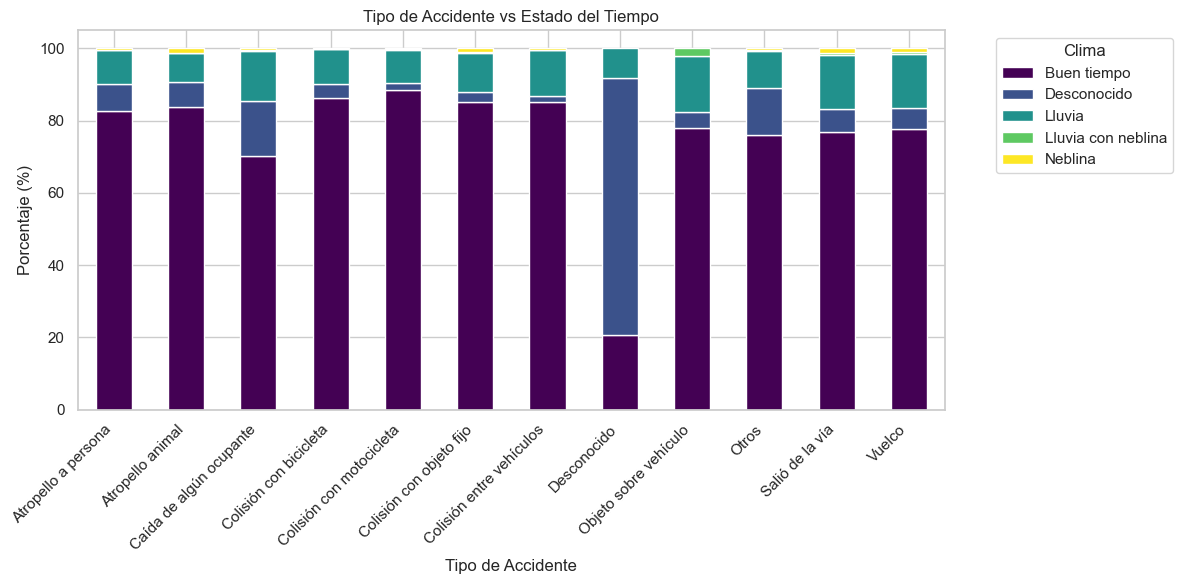

In [55]:
plt.figure(figsize=(14,7))
ct = pd.crosstab(df['Tipo de accidente'], df['Estado del tiempo'], normalize='index') * 100
ct.plot(kind='bar', stacked=True, colormap='viridis')
plt.title('Tipo de Accidente vs Estado del Tiempo')
plt.ylabel('Porcentaje (%)')
plt.xlabel('Tipo de Accidente')
plt.legend(title='Clima', bbox_to_anchor=(1.05,1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()